Julieta Madrigal Flores

Rodolfo Del Castillo Wilches

# **Modelos de Opciones: Black-Scholes, Heston y Merton**

Comparación de las distribuciones de precios finales bajo tres modelos:
- **Black-Scholes (GBM):** volatilidad constante, distribución log-normal
- **Heston:** volatilidad estocástica — genera fat tails y skew negativo
- **Merton:** difusión + saltos de Poisson — genera colas asimétricas y crashes abruptos

## Distribución real vs. log-normal

La distribución empírica de retornos de SPY tiene dos características que BS ignora:
- **Curtosis excesiva > 0:** las colas son más gordas que la normal
- **Asimetría negativa:** los retornos negativos extremos son más frecuentes que los positivos equivalentes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import yfinance as yf

In [ ]:
# Descargamos 10 años de datos de SPY para analizar los retornos reales
data     = yf.Ticker('SPY').history(period='10y')['Close']
retornos = data.pct_change().dropna()

print(f"Curtosis excess :{kurtosis(retornos):.2f}   (normal = 0)")
print(f"Asimetría       :{skew(retornos):.2f}    (normal = 0)")

Curtosis excess :15.14   (normal = 0)
Asimetría       :-0.32    (normal = 0)


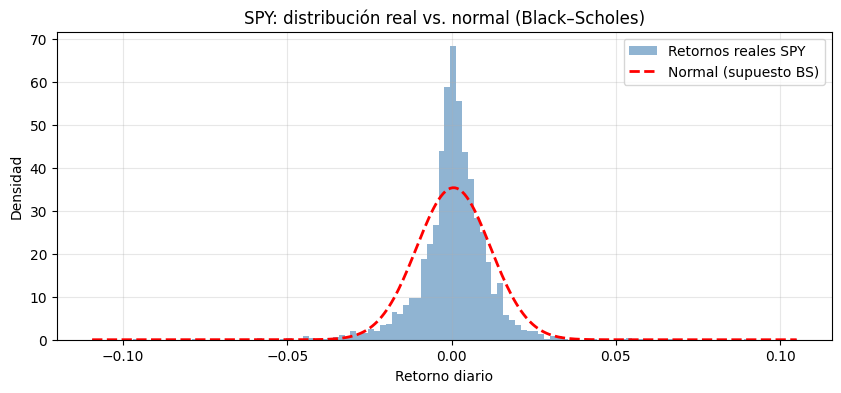

In [ ]:
x = np.linspace(retornos.min(), retornos.max(), 300)
plt.figure(figsize=(10, 4))
plt.hist(retornos, bins=120, density=True, alpha=0.6,
         color='steelblue', label='Retornos reales SPY')
plt.plot(x, norm.pdf(x, retornos.mean(), retornos.std()),
         'r--', linewidth=2, label='Normal (supuesto BS)')
plt.xlabel('Retorno diario')
plt.ylabel('Densidad')
plt.title('SPY: distribución real vs. normal (Black–Scholes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Modelo de Heston — simulación base (parámetros de clase)

Observa que la distribución de Heston tiene colas más anchas que GBM,
especialmente hacia la izquierda. Esa asimetría es el skew negativo generado
por la correlación negativa entre precio y volatilidad (ρ = −0.7).

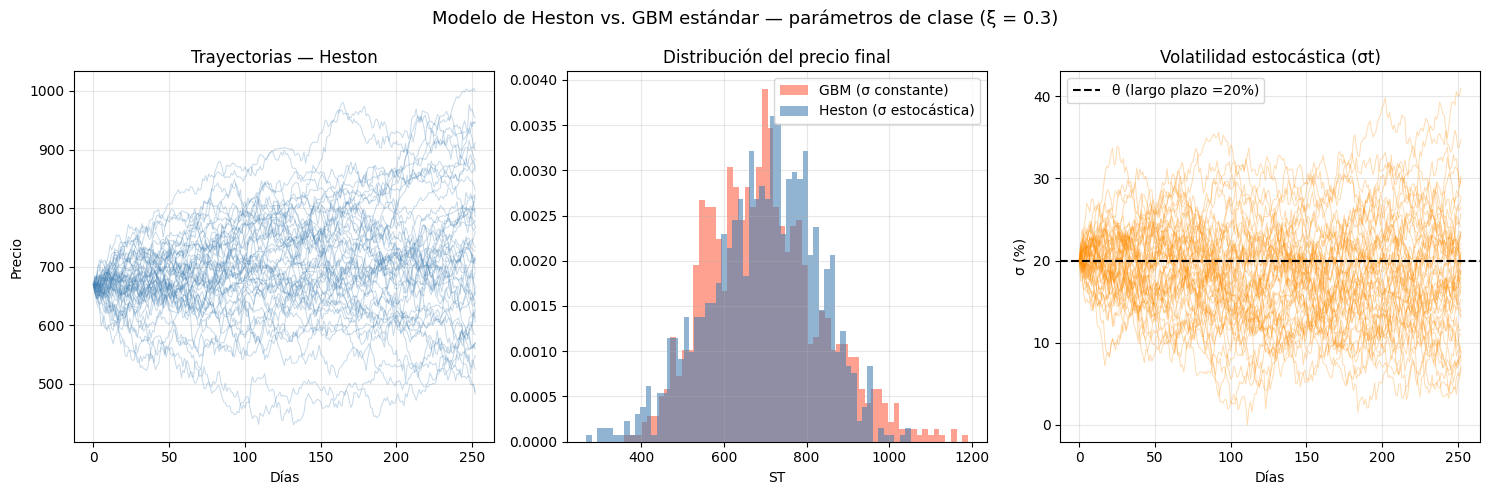

In [ ]:
def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación entre precio y varianza

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        # Actualización de la varianza (proceso CIR)
        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        # Actualización del precio con volatilidad estocástica
        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros de clase
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = 0.3    # vol of vol base
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

# GBM estándar (Black-Scholes) como referencia para todas las comparaciones
sigma_const = 0.20
dt = T / N
np.random.seed(42)
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1))
S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: trayectorias simuladas de Heston
for i in range(50):
    axes[0].plot(S_heston[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Panel 2: distribución del precio final GBM vs Heston
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM (σ constante)')
axes[1].hist(S_heston[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: evolución de la volatilidad estocástica en el tiempo
for i in range(50):
    axes[2].plot(np.sqrt(v_heston[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Modelo de Heston vs. GBM estándar — (ξ = 0.3)', fontsize=13)
plt.tight_layout()
plt.show()

# Modelo de Merton — simulación base (parámetros de clase)

**Trayectorias:** se ven discontinuidades abruptas — caídas verticales que no llegan gradualmente sino de golpe. Esos son los saltos de Poisson.

**Distribución final:** Merton desplaza la distribución hacia la izquierda porque los saltos tienen media negativa (μⱼ = −0.05). La cola izquierda es mucho más gruesa que en GBM — ese es el riesgo de crash que BS subestima sistemáticamente.

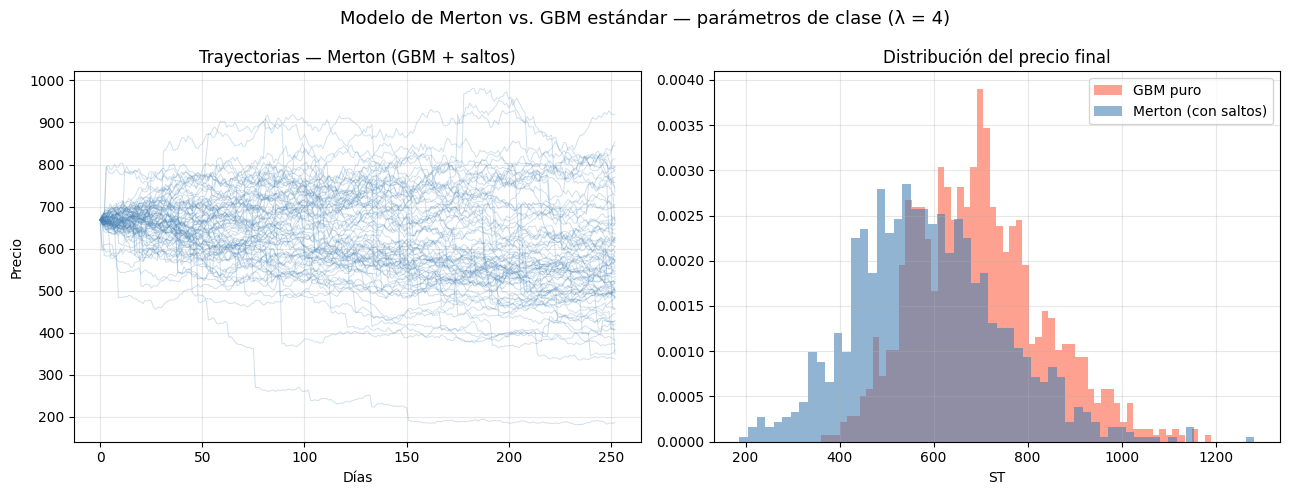

In [ ]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos: número de saltos en dt sigue una Poisson(λ·dt)
        n_saltos  = np.random.poisson(lam * dt, M)
        # Tamaño de cada salto es log-normal; se suman si hay más de uno
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        # Precio actualizado combinando difusión y saltos
        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros de clase
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam     = 4        # ~4 saltos por año
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: trayectorias — se pueden ver las caídas abruptas por saltos
for i in range(80):
    axes[0].plot(S_merton[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Panel 2: distribución final — Merton tiene cola izquierda más gruesa que GBM
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM puro')
axes[1].hist(S_merton[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Modelo de Merton vs. GBM estándar —  (λ = 4)', fontsize=13)
plt.tight_layout()
plt.show()

# Variaciones del modelo Heston — efecto de ξ (vol of vol)

Se prueba con ξ = 0.1, 0.4 y 0.9 manteniendo todos los demás parámetros fijos.

### Variación Heston: ξ = 0.1 (vol of vol baja)

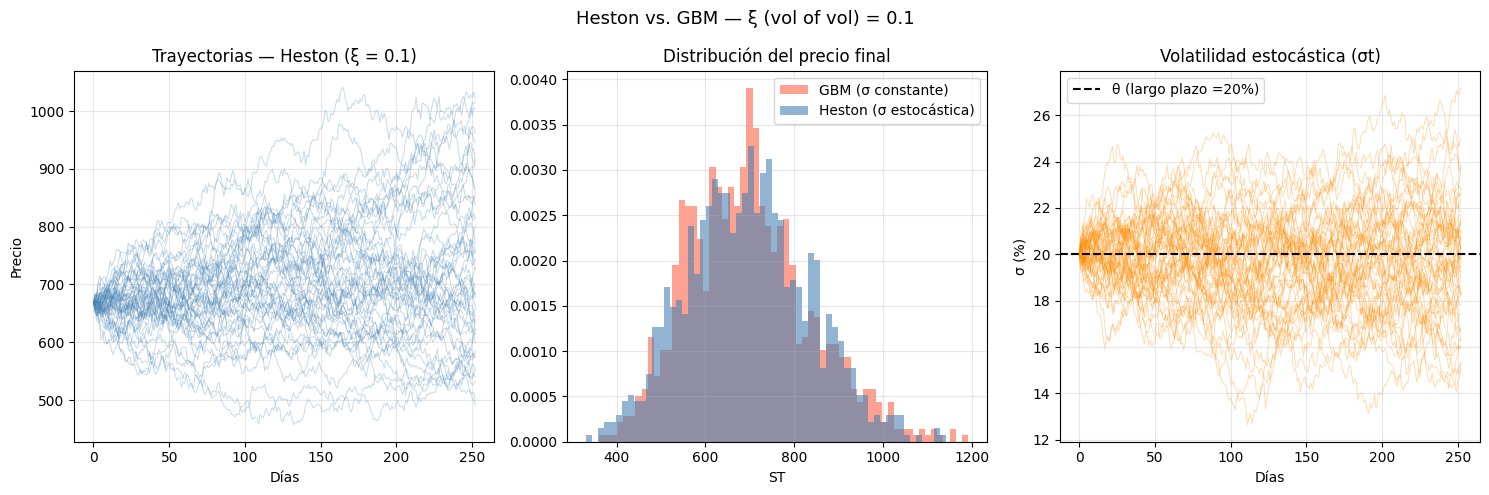

In [ ]:
# Con xi pequeño la varianza apenas fluctúa; Heston se comporta casi como GBM

S_heston_xi01, v_heston_xi01 = simular_heston(S0, v0, mu, kappa, theta, 0.1, rho, T, N, M)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(50):
    axes[0].plot(S_heston_xi01[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston (ξ = 0.1)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],         bins=60, density=True, alpha=0.6,
             color='tomato',         label='GBM (σ constante)')
axes[1].hist(S_heston_xi01[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue',      label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for i in range(50):
    axes[2].plot(np.sqrt(v_heston_xi01[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Heston vs. GBM — ξ (vol of vol) = 0.1', fontsize=13)
plt.tight_layout()
plt.show()

### Variación Heston: ξ = 0.4 (vol of vol media-alta)

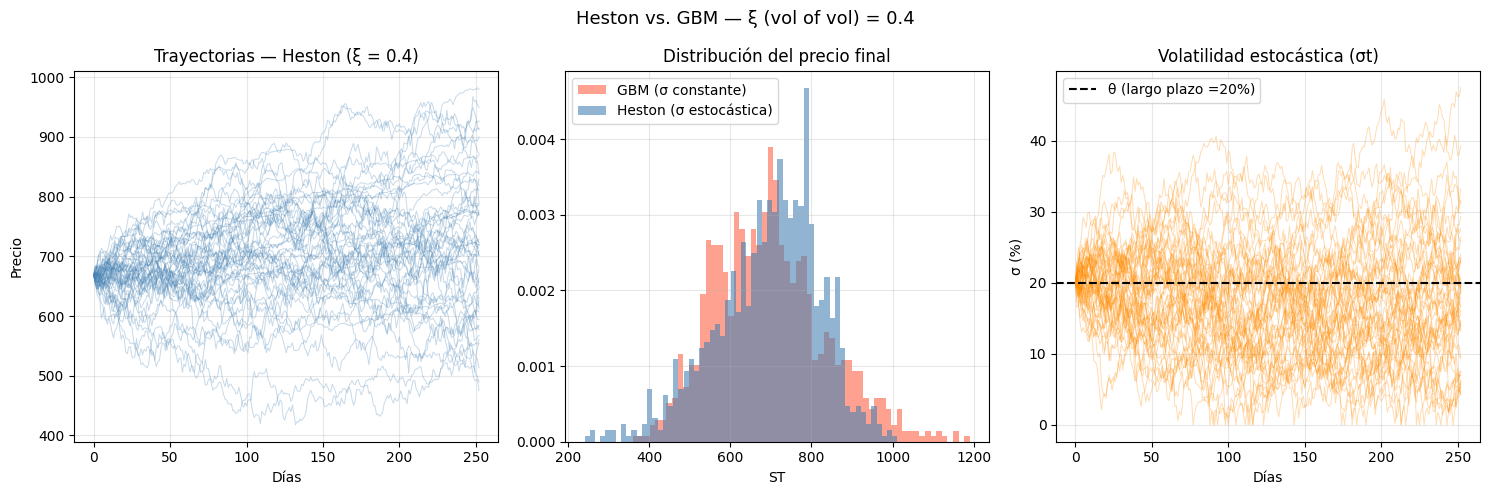

In [ ]:
# Las colas empiezan a ensancharse y el skew negativo se hace más visible

S_heston_xi04, v_heston_xi04 = simular_heston(S0, v0, mu, kappa, theta, 0.4, rho, T, N, M)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(50):
    axes[0].plot(S_heston_xi04[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston (ξ = 0.4)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],         bins=60, density=True, alpha=0.6,
             color='tomato',         label='GBM (σ constante)')
axes[1].hist(S_heston_xi04[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue',      label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for i in range(50):
    axes[2].plot(np.sqrt(v_heston_xi04[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Heston vs. GBM — ξ (vol of vol) = 0.4', fontsize=13)
plt.tight_layout()
plt.show()

### Variación Heston: ξ = 0.9 (vol of vol muy alta)

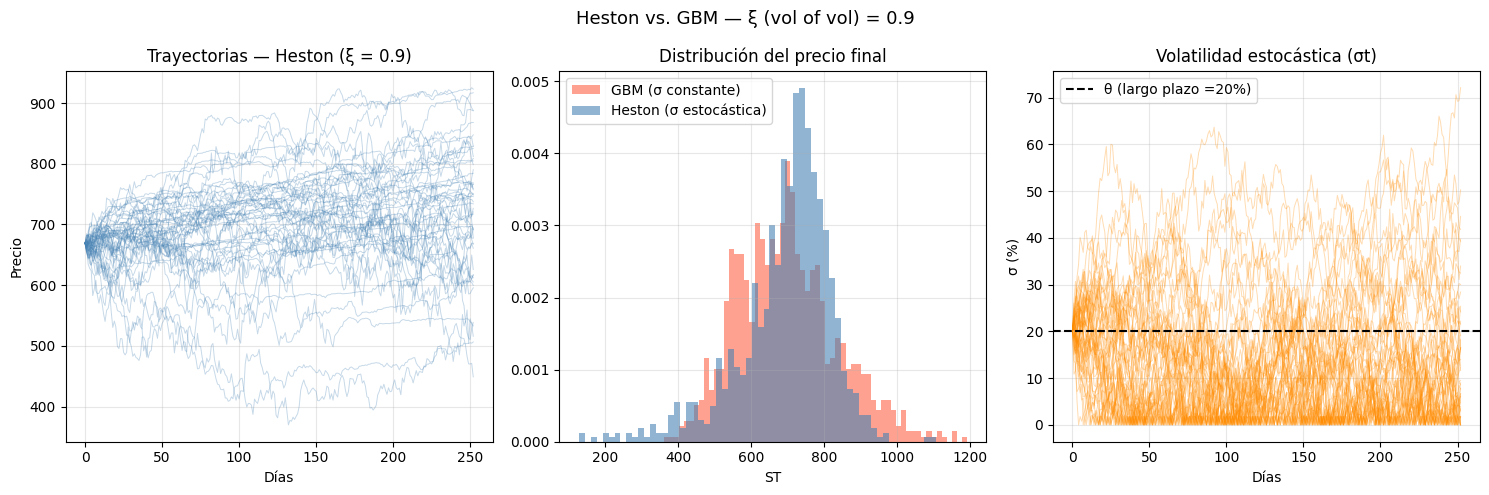

In [ ]:
# La varianza fluctúa enormemente
# colas mucho más gruesas y skew negativo amplificado
# porque ρ negativo hace que caídas de precio coincidan con picos de volatilidad

S_heston_xi09, v_heston_xi09 = simular_heston(S0, v0, mu, kappa, theta, 0.9, rho, T, N, M)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(50):
    axes[0].plot(S_heston_xi09[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston (ξ = 0.9)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],         bins=60, density=True, alpha=0.6,
             color='tomato',         label='GBM (σ constante)')
axes[1].hist(S_heston_xi09[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue',      label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for i in range(50):
    axes[2].plot(np.sqrt(v_heston_xi09[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Heston vs. GBM — ξ (vol of vol) = 0.9', fontsize=13)
plt.tight_layout()
plt.show()

# Variaciones del modelo Merton — efecto de λ (intensidad de saltos)

Se prueba con λ = 1, 4 y 15 manteniendo todos los demás parámetros fijos.

### Variación Merton: λ = 1 (saltos muy poco frecuentes aprox 1 por año)

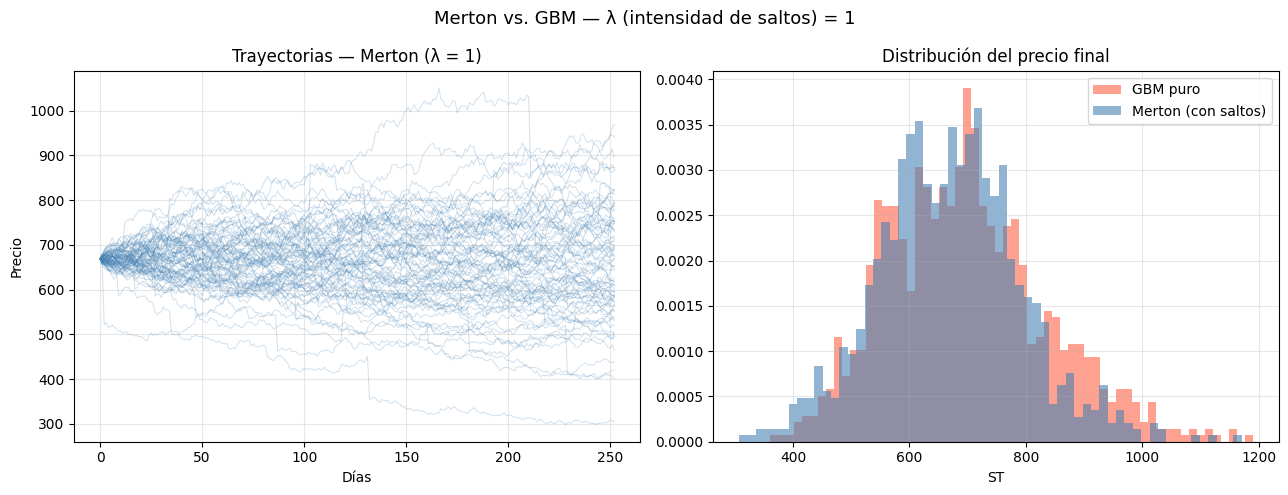

In [ ]:
# La mayoría de trayectorias no experimentan ningún salto;
# la distribución final es muy parecida a GBM

S_merton_lam1 = simular_merton(S0, mu, sigma, 1, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i in range(80):
    axes[0].plot(S_merton_lam1[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (λ = 1)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],         bins=60, density=True, alpha=0.6,
             color='tomato',         label='GBM puro')
axes[1].hist(S_merton_lam1[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue',      label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Merton vs. GBM — λ (intensidad de saltos) = 1', fontsize=13)
plt.tight_layout()
plt.show()

### Variación Merton: λ = 4 (parámetros de clase aprox 4 saltos por año)

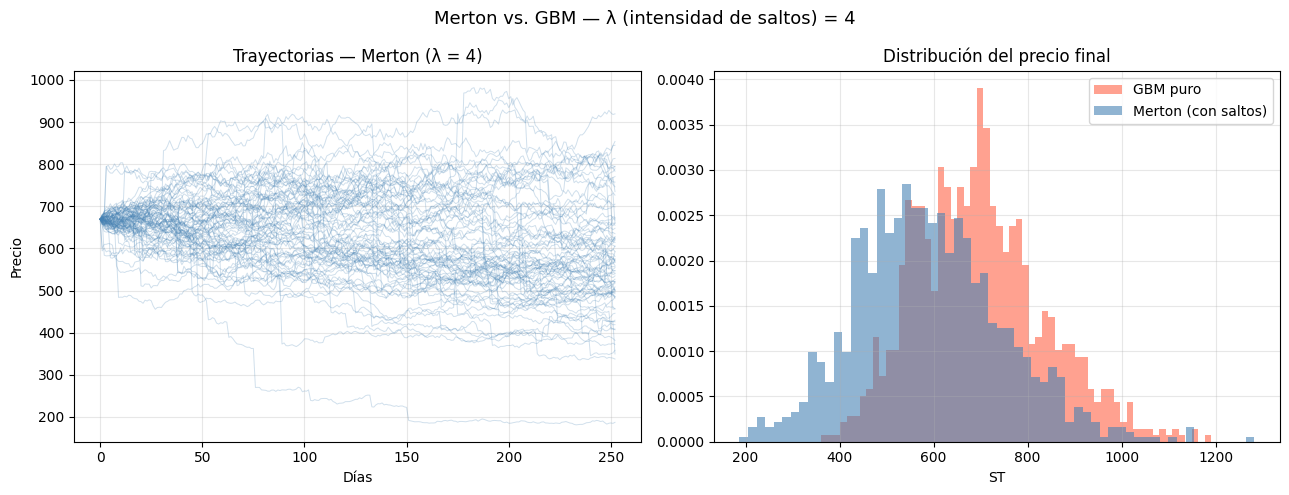

In [ ]:
# Saltos ocasionales visibles en trayectorias; distribución desplazada a la izquierda

S_merton_lam4 = simular_merton(S0, mu, sigma, 4, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i in range(80):
    axes[0].plot(S_merton_lam4[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (λ = 4)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],         bins=60, density=True, alpha=0.6,
             color='tomato',         label='GBM puro')
axes[1].hist(S_merton_lam4[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue',      label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Merton vs. GBM — λ (intensidad de saltos) = 4', fontsize=13)
plt.tight_layout()
plt.show()

### Variación Merton: λ = 15 (saltos muy frecuentes aprox 15 por año) ─

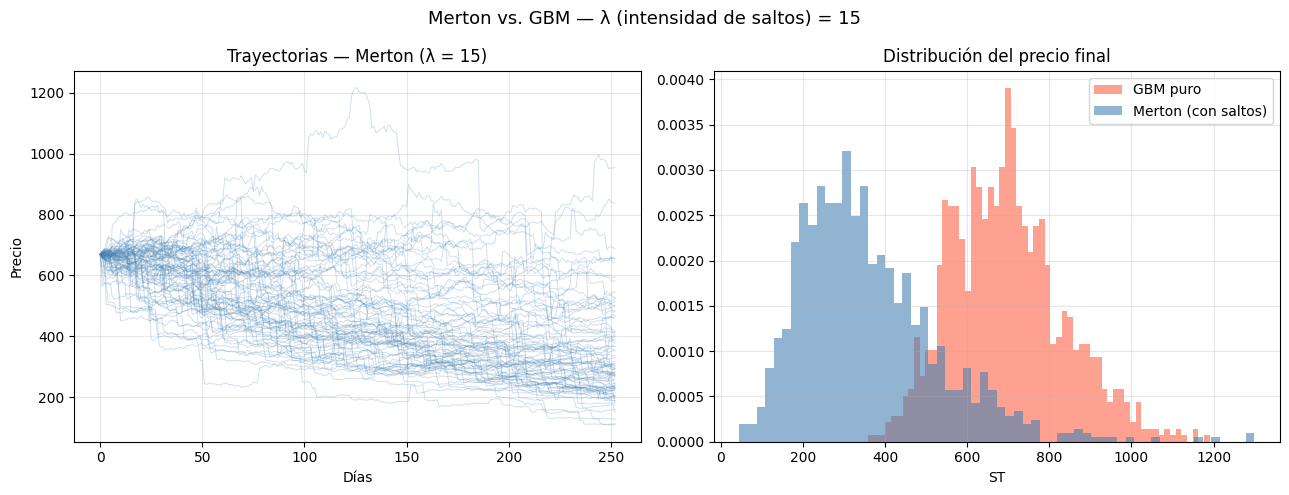

In [ ]:
# Los saltos negativos se acumulan constantemente; la distribución se desplaza
# notablemente a la izquierda y la cola izquierda se engrosa respecto a GBM

S_merton_lam15 = simular_merton(S0, mu, sigma, 15, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i in range(80):
    axes[0].plot(S_merton_lam15[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (λ = 15)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

axes[1].hist(S_gbm[:, -1],          bins=60, density=True, alpha=0.6,
             color='tomato',          label='GBM puro')
axes[1].hist(S_merton_lam15[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue',       label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Merton vs. GBM — λ (intensidad de saltos) = 15', fontsize=13)
plt.tight_layout()
plt.show()

# Preguntas

**1. ¿Qué efecto tiene aumentar ξ sobre la distribución y el skew en Heston?**

Al comparar las tres gráficas se lográ identificar que con ξ = 0.1 la
distribución de Heston es casi idéntica a la de GBM, se superponen tanto
que casi no tiene caso compararlas. La volatilidad apenas se mueve
del 20%, como si fuera constante pero esto se puede deber a que si la vol of vol es casi cero, Heston colapsa a Black-Scholes.

Con ξ = 0.4 la distribución de Heston se aplana un poco, la cola izquierda se engrosa y la volatilidad empieza a oscilar entre 0% y casi 40% en algunas trayectorias.

Con ξ = 0.9 el cambio es evidente porque la distribución ya no se parece a GBM, está más dispersa, más aplana y con una cola izquierda claramente más gruesa. La volatilidad llega a dispararse hasta 70% en algunos caminos. El skew negativo se acentúa porque ρ = −0.7, es decir cada vez que el precio cae, la volatilidad sube, y con ξ alto esa subida es mucho más violenta, generando caídas más extremas y engrosa la cola izquierda desproporcionadamente.

**2. En Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias y la distribución?**

Con λ = 4 los saltos son eventos puntuales, las trayectorias se ven como
caídas abruptas ocasionales pero entre salto y salto el precio se comporta
casi como GBM. La distribución final se corre a la izquierda respecto a GBM
pero todavía hay bastante solapamiento.

Al subir λ a 15 las trayectorias caen de forma casi
continua y sistemática, además la distribución final se separa completamente de GBM. Merton se concentra entre 200 y 600 mientras GBM está entre 600 y 900.

Con λ = 10 las trayectorias tienen caídas bastante frecuentes, ya sin la apariencia suave del GBM y con una distribución hacia la izquierda con la media notablemente más baja que BS.

**3. ¿El precio BS de un put muy OTM está sobreestimado o subestimado?**

Subestimado =

En Merton con λ = 15 hay masa de probabilidad real concentrada entre 200 y 400, precios donde un put muy OTM tendría un valor enorme. En GBM esa misma región tiene densidad prácticamente cero, como si esos escenarios fueran imposibles.

En Heston con ξ = 0.9: la cola izquierda llega hasta 400 o menos,
mientras BS ni se acerca a esos niveles.

BS está calculando la prima de ese put como si las caídas extremas no
pudieran pasar, cuando en realidad sí pasan. El mercado lo sabe y lo corrige exigiendo más volatilidad implícita en strikes bajos, como volatility skew en opciones reales.

**4. ¿Qué limitación tiene asumir λ constante en Merton?**

A partir de las gráficas λ = 15, los saltos están repartidos uniformemente a lo largo de los 252 días, la caída es gradual y pareja pero eso no es real. En 2008 o en marzo de 2020 los crashes ocurrieron en
cuestión de días, no distribuidos tranquilamente durante todo el año.

El problema de λ constante es que se asume que los saltos llegan a
ritmo fijo sin importar el contexto. En épocas de calma sobreestima el riesgo pero en momentos de pánico real, cuando los saltos se encadenan uno tras otro, lo subestima. Para capturar esa dinámica de clústeres harían falta modelos donde λ cambie en el tiempo o aumente después de cada salto.

**5. ¿Por qué BS sigue siendo el estándar si Heston y Merton son más precisos?**

1. **Velocidad**
BS tiene una fórmula directa solo metes los números y sale el precio. Mientras que Heston y Merton necesitan simular miles de trayectorias o resolver ecuaciones numéricas complejas para cada opción.

2. **Lenguaje común**
El mercado lleva años hablando en "volatilidad implícita de BS", que auqnue no es perfecto, todos están acostumbrados a eso y están bien con eso porque todos entienden. Cambiar ese estándar requeriría que TODOS adoptaran el mismo modelo alternativo al mismo tiempo, lo cual es prácticamente imposible de coordinar.

3. **El parche del volatility smile**
A pesar de que los traders saben que BS está mal, en lugar de cambiar el modelo, le agregan una corrección manual: cobran más volatilidad implícita en opciones OTM que en opciones ATM. Eso se define como volatility smile/skew que ves en el mercado real; es decir, usan BS sabiendo que miente, pero ajustan el input (la vol) para que el output (el precio) sea correcto.


Finalmente, BS no es el estándar porque sea el mejor modelo, sino porque es conveniente, universal y los traders ya aprendieron a corregir sus errores manualmente.